# Examples from TDS-CONTROL


## Contents

[Chapter 2](#chapter-2-stability-analysis-using-a-spectral-approach)
1. [Example 2.1](#example-21-stability-analysis-of-a-retarded-dde)
2. [Example 2.2](#example-22-more-information-on-the-option-max_size_evp-of-tds_roots)
3. [Example 2.3](#example-23-computing-the-characteristi-roots-of-a-quasi-polynomial)
4. [Example 2.4](#example-24-computing-the-characteristic-roots-of-a-neutral-dde)
5. [Example 2.5](#example-25-relation-between-the-characteristic-roots-of-a-neutral-dde-and-the-characteristic-roots-of-its-underlying-delay-difference-equation)
6. [Example 2.6](#example-26-stability-analysis-of-a-neutral-dde-with-multiple-delays)
7. [Example 2.7](#example-27-strong-stability-analysis-for-a-neutral-dde-with-multiple-delays)
8. [Example 2.8](#example-28-computing-characteristic-roots-of-an-ndde-in-a-given-rhp)
9. [Example 2.9](#example-29-from-tds-control-manual)
10. [Example 2.10](#example-210-computing-the-roots-of-a-quasipolynomial)
11. [Example 2.11](#example-211-computing-the-transmission-zeros)
12. [Example 2.12](#example-212-delay-mismatch-problem-for-a-smith-predictor)

[Chapter 3](#chapter-3-stabilization-using-direct-optimization)



In [2]:
# Imports

import numpy as np
import tdspy
import tdspy.plot

from tdspy.stability.characteristic_roots import rightmost_root

# Set up logging
# Change to DEBUG for DEBUG messages
# Change to INFO for INFO messages

tdspy.init_logger(level="WARNING")      
                                        

<Logger tdspy (WARNING)>

## Chapter 2 Stability analysis using a spectral approach


### Example 2.1 Stability analysis of a retarded DDE

We will analyze the exponential stability of the following RDDE from [1,
Section 6.1]: 

    x'(t) = A0 x(t) + A1 x(t-1)

    A0 = [  -1  0   0       0   ]       A1  =   [    3   3       3   3   ]
         [  0   1   0       0   ]               [    0   -1.5    0   0   ]
         [  0   0   -10     -4  ]               [    0   0       3   -5  ]
         [  0   0   4       -10 ]               [    0   5       5   5   ]

[1] Verheyden K., Luzyanina T., and Roose D. (2008). Efficient
    computation of characteristic roots of delay differential equations
    using LMS methods. Journal of Computational and Applied Mathematics,
    214(1), pp. 209–226.  

rightmost roots is (0.6176424667760778+1.1048670745192008e-14j)


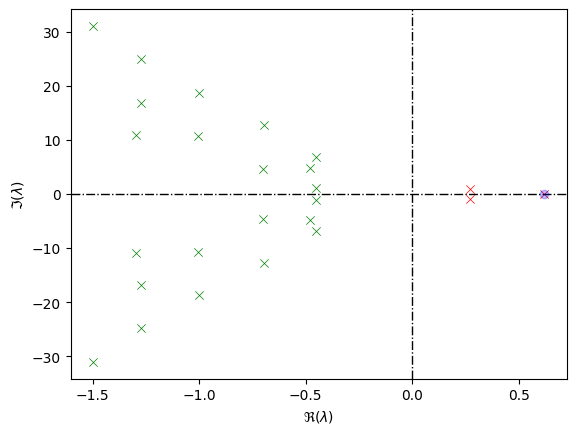

In [3]:
# Imports

import numpy as np
import tdspy
import tdspy.plot

from tdspy.stability.characteristic_roots import rightmost_root

# Create DDAE Representation

A0 = np.array([[-1, 0, 0, 0],
               [0, 1, 0, 0],
               [0, 0, -10, -4],
               [0, 0, 4, -10]])         # A0 - 2D array

A1 = np.array([[3, 3, 3, 3],
               [0, -1.5, 0, 0],
               [0, 0, 3, -5],
               [0, 5, 5, 5]])           # A1 - 2D array

A = np.stack([A0, A1], axis=2)          # A0, A1 - stack them into the array A
                                        # A = [A0 ; A1]
hA = np.array([0,1.])                   # hA - 1D array
r = -1.5

A = np.stack([A0, A1], axis=2)
hA = np.array([0,1.])
r = -1.5
ddae = tdspy.DDAE(A=A, hA=hA)
rdde = tdspy.RDDE(A=A, hA=hA)
cr, info = tdspy.roots(ddae, r=r)

z, z_info = rightmost_root(E=rdde.E, A=rdde.A, hA=rdde.hA, r=r)
print(f"rightmost roots is {z}")

import matplotlib.pyplot as plt

tdspy.plot.eigen_plot(cr)
plt.plot([np.real(z)], [np.imag(z)], "bo", alpha=0.25)

plt.show()


### Example 2.2: More information on the option max_size_evp of tds_roots

Consider the same differential equation from above, but now compute the characteristic roots in the right half-plane \{$\lambda \in \mathbb{C}: \Re(\lambda) \geq -4.5$\}

(Notice the warning about the size of the EVP)

2025-08-14 11:38:00,218 - tdspy.stability.characteristic_roots - WARNING - Size of the generalized EVP would exceed its maximum value. Discretization around 0 + 0*1j with N = 149 instead (size of new eigenvalue problem: 600 x 600. As a consequence, not all characteristic roots in the specified right half-plane might be found. To make sure that all desired characteristic roots are found, either increase r (i.e., shift the desired right half-plane to the right) or increase the kwargs 'max_size_evp'. For more information consult the documentation of this function.


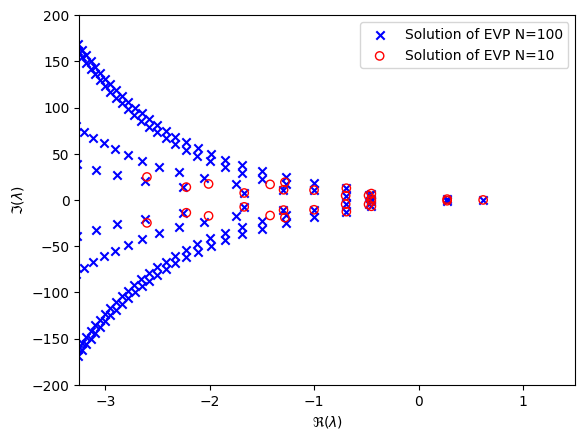

In [ ]:
r = -4.5
cr, info = tdspy.roots(ddae, r=r)


# For the animation
import matplotlib.animation as animation
import tdspy.plot as tdsplot
ani = tdsplot.discretization_animation(rdde, s0=0, discretization=range(10,85), discretization_ideal=100, xlim=(-3.25,1.5), ylim=(-200, 200))

ani
# writer = animation.PillowWriter(fps=30,
#                                  metadata=dict(artist='Me'),
#                                  bitrate=1800)
# ani.save('scatter.gif', writer=writer)

In [5]:
# Now change the max_size_evp to 2000
cr, info = tdspy.roots(ddae, r=r, max_size_evp=2000)

2025-08-14 11:38:45,413 - tdspy.stability.newton - WARNING - The Newton corrections failed to converge for root=(-4.685355349513199+672.748918808057j), final residual 0.7603578684910723


### Example 2.3: Computing the characteristi roots of a quasi-polynomial

We consider a quasi-polynomial: 
$\lambda^2+\omega^2-k e^{-\lambda 0.1}$

    h(lambda) = lambda^2 + omega^2 - k exp(-lambda x 0.1)

This can be represented by the QP:

    
    QP = Sum p_j (lambda) exp(-lambda tau_i)

                                        [   1       ]                       [   1       ]
    i.e. qp =   [ omega^2   0   1   ]   [   lambda  ] + [ -k     0   0   ]   [ lambda    ] exp(-lambda tau1)
                                        [   lambda^2]                       [lambda ^ 2 ]
    In MATLAB:
        qp = tds_create_qp([1 0 omega^2; 0 0 -k],[0 tau])

    In PYTHON:
                m-1                    n
        QP(s) =  SUM exp(-delays[i]*s) SUM coefs[i,j] * s**j
                i=0                   j=0


E 2x2 matrix
[[1. 0.]
 [0. 1.]]
--------------------------------------------------
A[:,:,0 - tau=0.0
[[ 0.  1.]
 [-4. -0.]]
--------------------------------------------------
A[:,:,1 - tau=0.1
[[ 0.  0.]
 [ 3. -0.]]
--------------------------------------------------


-0.15204638316856922

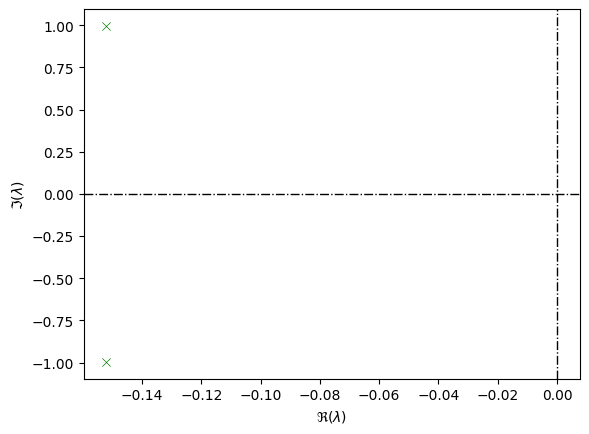

In [19]:
from scipy import linalg
import tdspy as tds
import numpy as np
from tdspy.common.quasipoly import compress_qp, qp_to_ndde
import tdspy.plot as tdsplot

tds.init_logger(level="WARNING")    

omega=2
k=3
tau=0.1

coeffs = np.array([[omega**2, 0., 1.],[-k, 0., 0.]])
delays = np.array([0.,tau])

A, hA, H, hH = qp_to_ndde(coeffs,delays,ascending=True)

ndde = tds.NDDE(A=A,hA=hA,H=H,hH=hH)
ddae = ndde.to_ddae()

cr, RootInfo = tds.roots(ddae,r=-2)

import matplotlib.pyplot as plt

plt = tdsplot.eigen_plot(cr)
ax = plt.axis
 
ndde.print()
np.max(np.real(cr))

### Example 2.4: Computing the characteristic roots of a neutral DDE

Neutral delay differential equations:
Consider the NDDE:

    x'(t) = [   -0.6    -0.45   ] x(t)  +   [   -0.15   0.075   ] x(t-1)    +   [   3       -1.5    ] x'(t-1)
            [   0.1     -1.2    ]           [   0.225   -0.75   ]               [   2.5     -1      ]

<Axes: xlabel='$\\Re (\\lambda)$', ylabel='$\\Im (\\lambda)$'>

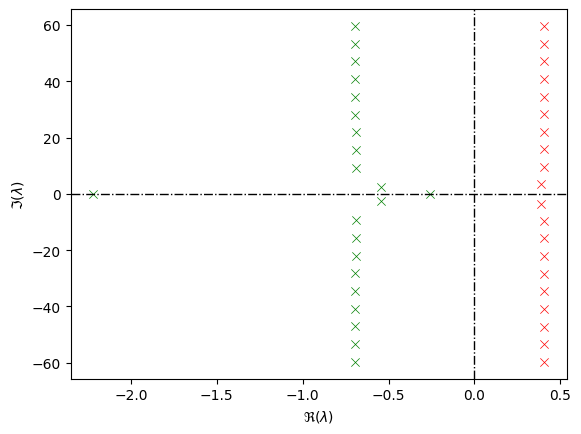

In [16]:
import numpy as np
import tdspy as tds
tdspy.init_logger(level="WARNING")    

A0 = np.array([[    -0.6,   -0.45   ],
                [    0.1,    -1.2   ]])
A1 = np.array([[    -0.15,  0.075   ],
                [   0.225,  -0.75   ]])
A = np.stack([A0,   A1],    axis=2)
hA = np.array([0.,  1.])

H = np.stack([np.array([[3,-1.5],[2.5,-1]])],axis=2)
hH = np.array([1.])

ndde = tds.NDDE(A=A,hA=hA,H=H,hH=hH)

ddae = ndde.to_ddae()

cr, RootsInfo = tds.roots(ddae,r=[-3,1,-60,60])

tdspy.plot.eigen_plot(cr)



### Example 2.5: Relation between the characteristic roots of a neutral DDE and the characteristic roots of its underlying delay difference equation

The associated delay difference equation is given by

    x(t) +  [   3       -1.5    ] x(t-1)    =   0
            [   2.5     -1      ]

How do we obtain the delay difference equation from the above?


<Axes: xlabel='$\\Re (\\lambda)$', ylabel='$\\Im (\\lambda)$'>

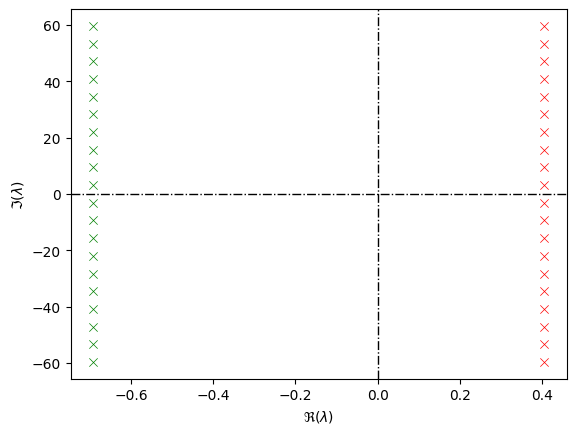

In [17]:
dde = ddae.get_delay_difference_equation()

crd, RootsInfo = tds.roots(dde,r=[-3,1,-60,60])
crd
tdspy.plot.eigen_plot(crd)

# plt.plot([np.real(crd)], [np.imag(crd)], "bo", alpha=0.25)


### Example 2.6: Stability analysis of a neutral DDE with multiple delays

Consider the NDDE with multiple delays

    x'(t) =     1/4 x(t) - 1/3 x(t-tau1) + 3/4 x'(t-tau1) - 1/2 x'(t-tau2)

with $\tau_1=1$, $\tau_2=2$

We reframe the above equation and bring it to the form

    x'(t) - 3/4 x'(t-tau1) + 1/2 x'(t-tau2) = 1/4 x(t) - 1/3 x(t-tau1)

<Axes: xlabel='$\\Re (\\lambda)$', ylabel='$\\Im (\\lambda)$'>

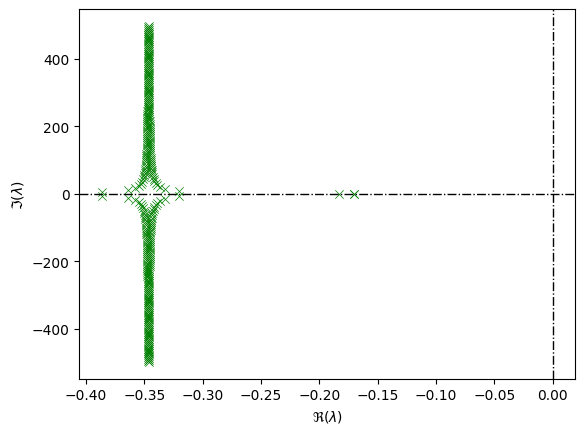

In [21]:
import tdspy as tds
import numpy as np
import tdspy.plot as plt

tds.init_logger(level="WARNING")

# Define parameters
tau1, tau2 = 1., 2.

# Define matrices A0, A1
A0 = np.array([[1/4]])
A1 = np.array([[-1/3]])
A = np.stack([A0,A1],axis=2)
hA = np.array([0,tau1])

# Define matrices H1, H2
H1 = np.array([[-3/4]])
H2 = np.array([[1/2]])
H = np.stack([H1,H2],axis=2)
hH = np.array([tau1,tau2])

# Build TDS
ndde = tds.NDDE(H=H,hH=hH,A=A,hA=hA)
# ddae = ndde.to_ddae()

r=[-0.9,0.2,-500,500]

cr, RootsInfo = tds.roots(ndde,r,max_size_evp=1500)

tds.plot.eigen_plot(cr)



2.05

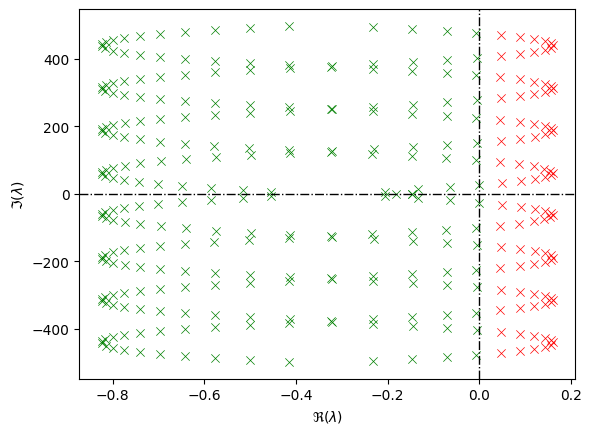

In [ ]:
# Now change the second delay to tau2=2.05

tau2 = 2.05
ndde.hH[1] = tau2
cr2, RootInfo = tds.roots(ndde,r,max_size_evp=1500) 

tds.plot.eigen_plot(cr2)
ndde.hH[1] = 2.05
ndde.hH[1]

<Axes: xlabel='$\\Re (\\lambda)$', ylabel='$\\Im (\\lambda)$'>

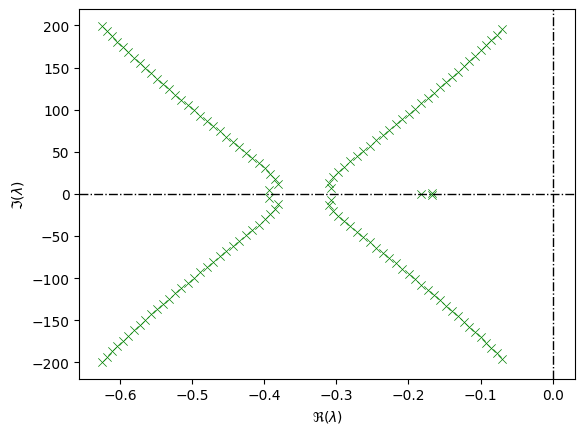

In [ ]:
# now change it to 2.005

tau2 = 2.005
ndde.hH[1] = 2.005

ndde.hH[1] = tau2
r = [-0.9,0.2,-200,200]
cr3, RootInfo = tds.roots(ndde,r,max_size_evp=1500) 

tds.plot.eigen_plot(cr3)


<Axes: xlabel='$\\Re (\\lambda)$', ylabel='$\\Im (\\lambda)$'>

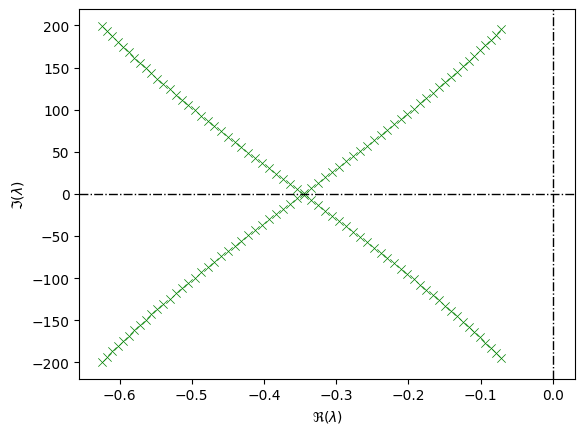

In [ ]:
# Let's check the underlying delay difference equation

delay_diff = ndde.get_delay_difference_equation()

cr4, RootsInfo = tds.roots(delay_diff,r,max_size_evp=1500)  
tds.plot.eigen_plot(cr4)


### Example 2.7: Strong stability analysis for a neutral DDE with multiple delays

Compute the strong spectral abscissa for the above NDDE


In [ ]:
tds.init_logger(level="INFO")
c = tds.strong_spectral_abscissa(ndde,-0.2)

gamma0 = tds.gamma(ndde,0)
gamma0

2025-08-14 12:20:40,194 - tdspy.stability.characteristic_roots - WARNING - gamma(r; ...)= 1.6619644174407626 exceeds 1 (i.e., CD>r). Spectral discretization with N = 30 (lowered if maximum size of eigenvalue problem is exceeded). Try specifying a rectangular region instead.
2025-08-14 12:20:40,194 - tdspy.stability.characteristic_roots - WARNING - gamma(r; ...)= 1.6619644174407626 exceeds 1 (i.e., CD>r). Spectral discretization with N = 30 (lowered if maximum size of eigenvalue problem is exceeded). Try specifying a rectangular region instead.
2025-08-14 12:20:40,194 - tdspy.stability.characteristic_roots - WARNING - gamma(r; ...)= 1.6619644174407626 exceeds 1 (i.e., CD>r). Spectral discretization with N = 30 (lowered if maximum size of eigenvalue problem is exceeded). Try specifying a rectangular region instead.
2025-08-14 12:20:40,194 - tdspy.stability.characteristic_roots - WARNING - gamma(r; ...)= 1.6619644174407626 exceeds 1 (i.e., CD>r). Spectral discretization with N = 30 (lower

num=array([[-1.75+1.2246468e-16j]])
[-1.75+1.2246468e-16j]
df=array([-1.75])
num=array([[-1.40163572+9.20294262e-17j]])
[-1.40163572+9.20294262e-17j]
df=array([-1.40163572])
num=array([[-1.36658449+8.90405219e-17j]])
[-1.36658449+8.90405219e-17j]
df=array([-1.36658449])
num=array([[-1.36198083+8.86490776e-17j]])
[-1.36198083+8.86490776e-17j]
df=array([-1.36198083])
num=array([[-1.36191432+8.86434243e-17j]])
[-1.36191432+8.86434243e-17j]
df=array([-1.36191432])
num=array([[-1.36191421+8.86434147e-17j]])
[-1.36191421+8.86434147e-17j]
df=array([-1.36191421])
num=array([[-1.36191421+8.86434147e-17j]])
[-1.36191421+8.86434147e-17j]
df=array([-1.36191421])


(1.25,
 GammaInfo(th=array([0.        , 3.14159265]), M=array([[-1.25+6.123234e-17j]]), s=(-1.25+6.123233995736766e-17j), u=array([1.+0.j]), v=array([1.-0.j])))

## Example 2.8: Computing characteristic roots of an NDDE in a given RHP

Compute the roots of the NDDE with real part greater than -0.6


2025-08-25 16:59:59,323 - tdspy.stability.characteristic_roots - WARNING - gamma(r; ...)= 3.0266475616611554 exceeds 1 (i.e., CD>r). Spectral discretization with N = 30 (lowered if maximum size of eigenvalue problem is exceeded). Try specifying a rectangular region instead.
2025-08-25 16:59:59,323 - tdspy.stability.characteristic_roots - WARNING - gamma(r; ...)= 3.0266475616611554 exceeds 1 (i.e., CD>r). Spectral discretization with N = 30 (lowered if maximum size of eigenvalue problem is exceeded). Try specifying a rectangular region instead.
2025-08-25 16:59:59,323 - tdspy.stability.characteristic_roots - WARNING - gamma(r; ...)= 3.0266475616611554 exceeds 1 (i.e., CD>r). Spectral discretization with N = 30 (lowered if maximum size of eigenvalue problem is exceeded). Try specifying a rectangular region instead.
2025-08-25 16:59:59,323 - tdspy.stability.characteristic_roots - WARNING - gamma(r; ...)= 3.0266475616611554 exceeds 1 (i.e., CD>r). Spectral discretization with N = 30 (lower

0.9398348977745473

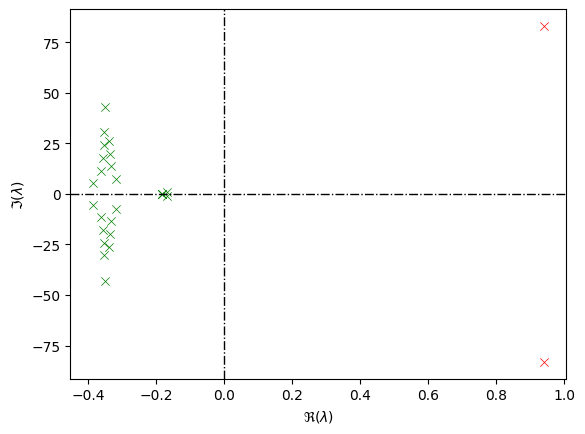

In [22]:
tau2 = 2
ndde.hH[1] = tau2
cr, RootInfo = tds.roots(ndde,-0.6)
tds.plot.eigen_plot(cr)
np.max(np.real(cr))

2025-08-25 17:07:00,087 - tdspy.stability.newton - WARNING - The Newton corrections failed to converge for root=(2.9832598994793553+24.885505233970093j), final residual 0.5542507807769913
2025-08-25 17:07:00,087 - tdspy.stability.newton - WARNING - The Newton corrections failed to converge for root=(2.9832598994793553+24.885505233970093j), final residual 0.5542507807769913
2025-08-25 17:07:00,087 - tdspy.stability.newton - WARNING - The Newton corrections failed to converge for root=(2.9832598994793553+24.885505233970093j), final residual 0.5542507807769913
2025-08-25 17:07:00,087 - tdspy.stability.newton - WARNING - The Newton corrections failed to converge for root=(2.9832598994793553+24.885505233970093j), final residual 0.5542507807769913
2025-08-25 17:07:00,087 - tdspy.stability.newton - WARNING - The Newton corrections failed to converge for root=(2.9832598994793553+24.885505233970093j), final residual 0.5542507807769913
2025-08-25 17:07:00,087 - tdspy.stability.newton - WARNING -

-0.170118046157833

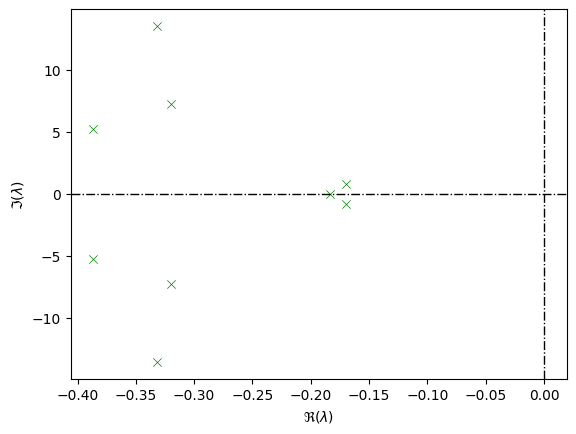

In [31]:
# to capture more characteristic roots, manually increase the 
# degree of spectral discretization to 200

# doesn't work if discretization = 200

ndde2 = ndde.to_ddae()
cr, RootInfo = tds.roots(ndde,-0.6, discretization=10)
tds.plot.eigen_plot(cr)
np.max(np.real(cr))

In [38]:
# taken from example 2.6

import tdspy as tds
import numpy as np

tds.init_logger(level="WARNING")

# Define parameters
tau1, tau2 = 1., 2.

# Define matrices A0, A1
A0 = np.array([[1/4]])
A1 = np.array([[-1/3]])
A = np.stack([A0,A1],axis=2)
hA = np.array([0,tau1])

# Define matrices H1, H2
H1 = np.array([[-3/4]])
H2 = np.array([[1/2]])
H = np.stack([H1,H2],axis=2)
hH = np.array([tau1,tau2])

# Build TDS
ndde = tds.NDDE(H=H,hH=hH,A=A,hA=hA)

ddae = ndde.to_ddae()

ddae = ddae.compress()
ddae.print_ddae()

E 2x2 matrix
[[0. 1.]
 [0. 0.]]
--------------------------------------------------
A[:,:,0 - tau=0.0
[[ 0.25  0.  ]
 [ 1.   -1.  ]]
--------------------------------------------------
A[:,:,1 - tau=1.0
[[-0.3333  0.    ]
 [-0.75    0.    ]]
--------------------------------------------------
A[:,:,2 - tau=2.0
[[0.  0. ]
 [0.5 0. ]]
--------------------------------------------------


### Example 2.9 from TDS-CONTROL Manual

DDAEs:
Consider the feedback interconnection of the form

$\dot{x}(t) = A_0 x(t) + A_1 x(t-1) +  B_{11} u(t-1)$

$y(t) = C_1 x(t) + D_{11} u(t-1)$

and the dynamic output feedback controller of the form

$\dot{x}(t) = A_c x_c(t) + B_c y(t)$

$u(t) = C_c x_c(t) + D_c y(t)$

with

$A_0 = \begin{bmatrix} 0.2 & 0.1 \\ -0.5 & 1 \end{bmatrix} $,
$A_1 = \begin{bmatrix} 0.5 & 0.3 \\ 0.1 & -0.1 \end{bmatrix}$, 
$B_{11} = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$,

$C_{10}=\begin{bmatrix}1 & 1 \end{bmatrix}$,
$D_{11} = \begin{bmatrix} 0.01 & 0.01 \end{bmatrix}$

and

$A_c = -3.48$, $B_c = 3.1$, 

$C_c = \begin{bmatrix} 1.79 \\ -0.09 \end{bmatrix}$, $D_c = \begin{bmatrix} -1.86 \\ -1.4 \end{bmatrix}$


In Pieter's method, he uses the augmented state vector 

$\tilde{x} = [x^T \ \zeta_y^T \ x_c^T \ \zeta_u^T]^T$

CD= -3.4234429906094754
-2.1640120572733297


<Axes: xlabel='$\\Re (\\lambda)$', ylabel='$\\Im (\\lambda)$'>

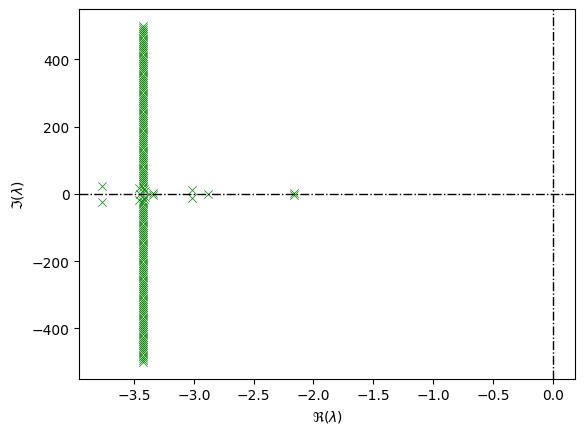

In [ ]:
import tdspy as tds
import numpy as np

# Define system matrices
A0 = np.array([[0.2,0.1],[-0.5,1]])
A1 = np.array([[0.5,0.3],[0.1,-0.1]])
A = np.stack([A0,A1],axis=2)
hA = np.array([0.,1.])

B0 = np.eye(2)
B = np.stack([B0],axis=2)
hB = np.array([0.])

C0 = np.array([[1,1]])
C = np.stack([C0],axis=2)
hC = np.array([0.])

D = np.stack([np.array([[0.01,0.01]])],axis=2)
hD = np.array([0.])

tau=1.

# Define controller matrices
Ac = np.array([[-3.48]])
Bc = np.array([[3.1]])
Cc = np.array([[1.79],[-0.09]])
Dc = np.array([[-1.86],[-1.4]])

# Obtain matrix sizes
n = np.shape(A0)[0]
p = np.shape(B)[1]
q = np.shape(C)[0]
nc = np.shape(Ac)[0]

# Forming closed-loop
n_CL = n+p+q+nc
E_CL = np.zeros([n_CL,n_CL])
E_CL[:n,:n]=np.eye(n)
idx = np.arange(n + q, n + q + nc)
E_CL[np.ix_(idx, idx)] = np.eye(nc)

A_CL_0 = np.zeros([n_CL,n_CL])
A_CL_0[:n,:n] = A0
A_CL_0[n:n+q,:n] = C[:,:,0]
idx = np.arange(n,n+q)

A_CL_0[np.ix_(idx,idx)] = -np.eye(q)
A_CL_0[np.ix_(n+q+np.arange(0,nc),n+np.arange(0,q))] = Bc
A_CL_0[np.ix_(n+q+np.arange(0,nc),n+q+np.arange(0,nc))] = Ac
A_CL_0[np.ix_(n+q+nc+np.arange(0,p),n+np.arange(0,q))] = Dc
A_CL_0[np.ix_(n+q+nc+np.arange(0,p),n+q+np.arange(0,nc))] = Cc
A_CL_0[np.ix_(n+q+nc+np.arange(0,p),n+q+nc+np.arange(0,p))] = -np.eye(p)


A_CL_1 = np.zeros_like(A_CL_0)
A_CL_1[:n,:n] = A1
A_CL_1[np.ix_(np.arange(0,n),n+q+nc+np.arange(0,p))] = B[:,:,0]
A_CL_1[np.ix_(n+np.arange(0,q),n+q+nc+np.arange(0,p))] = D[:,:,0]

A_CL = np.stack([A_CL_0,A_CL_1],axis=2)
hA_CL = np.array([0.,tau])

CL = tds.DDAE(E=E_CL,A=A_CL,hA=hA_CL)

diff = CL.get_delay_difference_equation()

CD,_ = tds.spectral_abscissa_diff(diff)
print("CD=",CD)

l_rect,_ = tds.roots(CL,r=[-4,0.5,-500,500],max_size_evp=2000)
print(np.max(np.real(l_rect)))

import tdspy.plot as plt

plt.eigen_plot(l_rect)


See and note that the strong spectral abscissa of the DDE matches the one in TDS-CONTROL

Now let's plot the roots

In [ ]:
diff = CL.get_delay_difference_equation()
diff.print_ddae()
CD = tds.spectral_abscissa_diff(diff)
print("CD=", CD)


E 2x2 matrix
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
--------------------------------------------------
A[:,:,0 - tau=0.0
[[-1.    0.    0.  ]
 [-1.86 -1.    0.  ]
 [-1.4   0.   -1.  ]]
--------------------------------------------------
A[:,:,1 - tau=1.0
[[0.   0.01 0.01]
 [0.   0.   0.  ]
 [0.   0.   0.  ]]
--------------------------------------------------
CD= (-3.4234429906094754, None)
E 2x2 matrix
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
--------------------------------------------------
A[:,:,0 - tau=0.0
[[ 0.2   0.1   0.    0.    0.    0.  ]
 [-0.5   1.    0.    0.    0.    0.  ]
 [ 0.    0.   -1.    0.    0.    0.  ]
 [ 0.    0.    3.1  -3.48  0.    0.  ]
 [ 0.    0.   -1.86  1.79 -1.   -0.  ]
 [ 0.    0.   -1.4  -0.09 -0.   -1.  ]]
--------------------------------------------------
A[:,:,1 - tau=1.0
[[ 0.5   0.3   0.    0.    1.    0.  ]
 [ 0.1  -0.1   0.    0.    0.    1.  ]
 [ 0.    0.    0.  

In [ ]:
CL.print()
print(tds.strong_spectral_abscissa(CL))

E 2x2 matrix
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
--------------------------------------------------
A[:,:,0 - tau=0.0
[[ 0.2   0.1   0.    0.    0.    0.  ]
 [-0.5   1.    0.    0.    0.    0.  ]
 [ 0.    0.   -1.    0.    0.    0.  ]
 [ 0.    0.    3.1  -3.48  0.    0.  ]
 [ 0.    0.   -1.86  1.79 -1.   -0.  ]
 [ 0.    0.   -1.4  -0.09 -0.   -1.  ]]
--------------------------------------------------
A[:,:,1 - tau=1.0
[[ 0.5   0.3   0.    0.    1.    0.  ]
 [ 0.1  -0.1   0.    0.    0.    1.  ]
 [ 0.    0.    0.    0.    0.01  0.01]
 [ 0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.  ]]
--------------------------------------------------
0.7503393318531009


2025-08-04 16:52:10,378 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,378 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,378 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,378 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,378 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,378 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8


<Axes: xlabel='$\\Re (\\lambda)$', ylabel='$\\Im (\\lambda)$'>

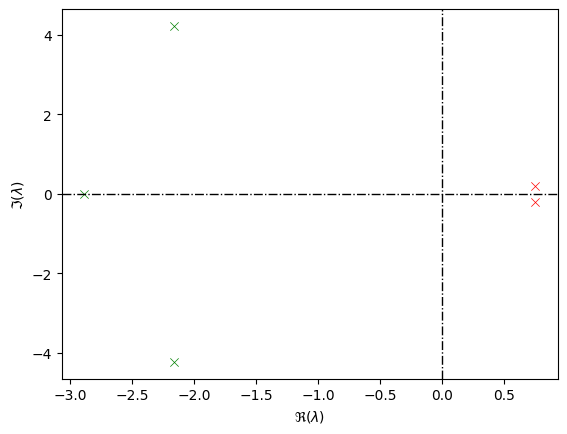

In [ ]:
l_rhp,_ = tds.roots(CL,r=-3,max_size_evp=2000)
plt.eigen_plot(l_rhp)


In [27]:
CL_sa = tds.strong_sa(CL,r=-2)
CL_sa           # should be = -0.2845

2025-08-04 16:52:10,531 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,531 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,531 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,531 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,531 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,531 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8


0.7503393318541645

A better way of creating the closed-loop is by using the function create_CL directly

Let
P = Open-loop plant
K = Dynamic controller

CL2 = Closed loop (P+K)

    P = tds.rdde(A=A,hA=hA,B=B,hB=hB,C=C,hC=hC,D=D,hD=hD)

In [ ]:

from tdspy.common.composition import concatenate_2x2_by_delays
from tdspy.stability.characteristic_roots import rightmost_root, RightmostRootInfo
import tdspy.controller as controller
from tdspy.controller import create_dynamic_controller

hA
P = tds.DDAE(A=A,hA=hA,B=B,hB=hB,C=C,hC=hC,D=D,hD=hD)
K = tds.DDAE(A=np.stack([Ac],axis=2),hA=np.array([0.]),
             B=np.stack([Bc],axis=2),hB=np.array([0.]),
             C=np.stack([Cc],axis=2),hC=np.array([0.]),
             D=np.stack([Dc],axis=2),hD=np.stack([0.]))
hK = np.array([0.])

cl = controller.interconnect(P,K)

diff2 = cl.get_delay_difference_equation()

CD2,_ = tds.spectral_abscissa_diff(diff2)

display(diff2.A[:,:,0],diff.A[:,:,0])

cl.A.shape
CL.A.shape

array([[ 1.  , -1.  ,  0.  ,  0.  ],
       [ 0.  ,  0.01, -1.  ,  0.  ],
       [ 0.  ,  0.  ,  1.  , -1.  ],
       [-1.  ,  0.  ,  0.  , -1.86]])

array([[-1.  ,  0.  ,  0.  ],
       [-1.86, -1.  ,  0.  ],
       [-1.4 ,  0.  , -1.  ]])

(6, 6, 2)

In [29]:
cont = controller.create_dynamic_controller(Ac,Bc,Cc,Dc)

cl2 = controller.interconnect(P,cont)

diff2 = cl2.get_delay_difference_equation()

cd = tds.cd(diff2)

cl2.hA[:] == cl.hA[:]

cl2.A[:,:,0].shape

(7, 7)

In [30]:
# cl = tds.ClosedLoop(P, order=1,K0=K, hK=hK)


In [31]:
cr,_=tds.roots(CL,r=-2)
f0 = np.max(np.real(cr))
f0

cr2,_=tds.roots(cl,r=-2)
f2 = np.max(np.real(cr2))
f2

2025-08-04 16:52:10,599 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,599 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,599 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,599 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,599 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,599 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,616 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,616 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 8
2025-08-04 16:52:10,616 - tdspy.stability.characteristic_roots - INFO - Degree o

1.1174195357031593

### Example 2.10 Computing the roots of a quasipolynomial

Consider the quasipolynomial given by

    lambda^2 -2 lambda + 1 + (-2 lambda + 2) e^{-lambda} + e^{-2 lambda}

In [32]:
coeffs = np.array([[1,-2,1],[0,-2,2],[0,0,1]])
delays = np.array([0.,1.,2.])

A, hA, H, hH = qp_to_ndde(coeffs,delays,ascending=False)

ndde = tds.NDDE(A=A,hA=hA,H=H,hH=hH)
cr, _ = tds.roots(ndde,r=-2)
f = np.max(np.real(cr))
f

2025-08-04 16:52:10,774 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 25
2025-08-04 16:52:10,774 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 25
2025-08-04 16:52:10,774 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 25
2025-08-04 16:52:10,774 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 25
2025-08-04 16:52:10,774 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 25
2025-08-04 16:52:10,774 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 25


1.27846457363625

### Example 2.11 Computing the transmission zeros

We consider a time-delay system of the form

$\dot{x}(t) = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 0 & 0 \\ 0& 1 & 0\end{bmatrix} x(t) + \begin{bmatrix}0&1&0\\0&0&0\\0&0&0 \end{bmatrix} x(t-1) + \begin{bmatrix}0\\1\\0\end{bmatrix} u(t)$

$y(t) = \begin{bmatrix}1 & 0 & 0 \end{bmatrix} x(t)$

2025-08-04 16:52:10,806 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 30
2025-08-04 16:52:10,806 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 30
2025-08-04 16:52:10,806 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 30
2025-08-04 16:52:10,806 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 30
2025-08-04 16:52:10,806 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 30
2025-08-04 16:52:10,806 - tdspy.stability.characteristic_roots - INFO - Degree of spectral discretization is N = 30


<Axes: xlabel='$\\Re (\\lambda)$', ylabel='$\\Im (\\lambda)$'>

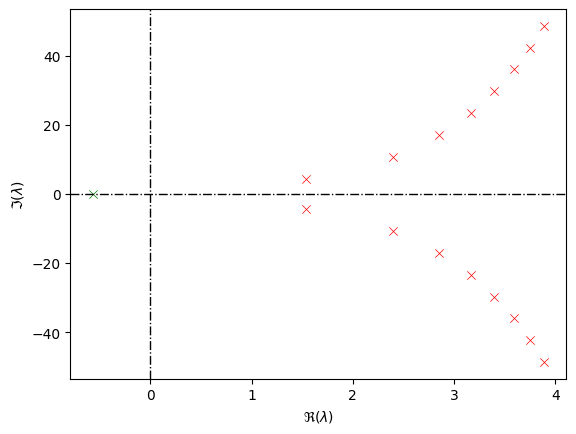

In [33]:
A0 = np.array([[1, 0, 1],
               [0, 0, 0],
               [0, 1, 0]])

A1 = np.array([[0,1,0],
               [0,0,0],
               [0,0,0]])

A = np.stack([A0,A1],axis=2)
hA = np.array([0,1.])

B0 = np.array([[0],[1],[0]])
B = np.stack([B0],axis=2)
hB = np.array([0.])

C0 = np.stack([[1,0,0]])
C = np.stack([C0],axis=2)
hC = np.array([0.])

D = np.zeros(shape=(1,1,1))
hD = np.array([0.])

rdde = tds.DDAE(A=A,hA=hA,B=B,hB=hB,C=C,hC=hC,D=D,hD=hD)

zr, zr_info = tds.zeros(rdde, r=[-4, 4, -50, 50])

plt.eigen_plot(zr)

In [34]:
zr

array([ 3.88711645+4.86148986e+01j,  3.88711645-4.86148986e+01j,
        3.74924254+4.23231454e+01j,  3.58926253+3.60290217e+01j,
        3.74924254-4.23231454e+01j,  3.39869185+2.97313106e+01j,
        3.58926253-3.60290217e+01j,  3.16295274+2.34277475e+01j,
        3.39869185-2.97313106e+01j,  2.85358176+1.71135355e+01j,
        3.16295274-2.34277475e+01j,  2.4015851 +1.07762995e+01j,
        2.85358176-1.71135355e+01j,  2.4015851 -1.07762995e+01j,
        1.53391332+4.37518515e+00j,  1.53391332-4.37518515e+00j,
       -0.56714329+5.49182976e-17j])

### Example 2.12 Delay-mismatch problem for a Smith predictor

Investigate the delay mismatch problem for:
                 1          B1(s)
    H0(s)  =   -----      = -----
               s + 1        A1(s)
                s           B2(s)
    C(s)    =  --- + 2    = -----
                2           A2(s)

The corresponding closed-loop transfer function is
                C(s) H0(s)
    Hcl(s) =  --------------- e^(-sT)
               1 + C(s) H0(s)

First formulate the corresponding QP

Then determine the stability of this quasi-polynomial by creating the corresponding state-space representation.



[25] W. Michiels and S.-I. Niculescu, “On the delay sensitivity of smith predictors,” International Journal of Systems Science, vol. 34, no. 8-9, pp. 543–551, 2003.



In [ ]:
import matplotlib.pyplot as plt
from tdspy.common.quasipoly import compress_qp, qp_to_ndde

tau, delta = 1., 0.5

coeffs = np.array([[3.,1.5],[2.0,0.5],[-2.0,-0.5]])
delays = np.array([0.,tau,tau+delta])

A, hA, H, hH = qp_to_ndde(coeffs,delays,ascending=True)

ndde = tdspy.NDDE(A=A,hA=hA,H=H,hH=hH)

ndde.print()

tau_grid = np.linspace(0,8,201)
delta_grid = np.linspace(-8,10,451)

Z = np.zeros((len(delta_grid), len(tau_grid)))

# for i2 in range(0,len(tau_grid)-1):
#     tau = tau_grid[i2]
#     for i1 in range(0,len(delta_grid)):
#         delta = delta_grid[i1]
#         if tau+delta<0:
#             # case: "real" delay cannot be negative
#             Z[i1,i2] = -np.inf
#         else:
#             hH[0], hH[1] = tau, tau+delta
#             hA[1], hA[2] = tau, tau+delta
#             ndde = qp_to_ndde(H=H,hH=hH,A=A,hA=hA)
#             Z[i1,i2] = tds.strong_spectral_abscissa(ndde)

# X, Y = np.meshgrid(tau_grid,delta_grid)


# plt.contour(X,Y,Z,[0,0])
# plt.plot(plt.xlim,[0,0],'k-.')


ValueError: could not broadcast input array from shape (2,) into shape (3,)

## Chapter 3: Stabilization using direct optimization


### Example 3.1 Heat transfer setup

xh'(t) = 1/Th (-xh(t-mu_h)) + Kb xa(t-tau_b) + Ku u(t-tau_u)
xa'(t) = 1/Ta (-xa(t) + xc(t-tau_e) + Ka (xh(t) - (1+q)/2 xa(t) - (1-q)/2 xc(t-tau_e)))
xd'(t) = 1/Td (-xd(t) + Kd xa(t-tau_d))
xc'(t) = 1/Tc (-xc(t-mu_c) + Kc xd(t-tau_c))
xi'(t) = xc_set - xc(t)

We assume xc_set = 0


###

In [33]:
# Defining the system
import tdspy as tds
import numpy as np
from tdspy.stability.characteristic_roots import rightmost_root

Th, Ta,Td, Tc = 14, 3, 3, 25
Kb, Ka, Kd, Kc, Ku = 0.24, 1, 0.94, 0.81, 0.39
nh, tb, te, td = 6.5, 40, 13, 18
tc, nc, tu = 2.8, 9.2, 13.2

hA, hB = np.array([0, nh, tb, te, td, tc, nc]), np.array([tu])

A0 = np.zeros([5,5])
A0[1,0], A0[1,1] = Ka/Ta, (-Ka-1)/Ta
A0[2,2], A0[4,3] = -1/Td, -1
A1, A1[0,0]     = np.zeros([5,5]), -1/Th
A2, A2[0,1]     = np.zeros([5,5]), Kb/Th
A3, A3[1,3]     = np.zeros([5,5]), 1/Ta
A4, A4[2,1]     = np.zeros([5,5]), Kd/Td
A5, A5[3,2]     = np.zeros([5,5]), Kc/Tc
A6, A6[3,3]     = np.zeros([5,5]), -1/Tc
A = np.stack([A0,A1,A2,A3,A4,A5,A6],axis=2)

B0 = np.array([[Ku/Th], [0.], [0.], [0.], [0.]])
B = np.stack([B0],axis=2)

C0 = np.eye(5)
C = np.stack([C0],axis=2)

D = np.zeros(shape=(5,1,1), dtype=float)    # must be defined, otherwise error!
hD = np.array([0.])

hC = np.array([0.])

plant = tds.DDAE(A=A,hA=hA,B=B,hB=hB,C=C,hC=hC,D=D,hD=hD)
plant.print()

# Finding the rightmost root
# z, z_info = rightmost_root(E=plant.E, A=plant.A, hA=plant.hA, r=-3)
# print(np.max(np.real(z)))

E 2x2 matrix
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
--------------------------------------------------
A[:,:,0 - tau=0.0
[[ 0.      0.      0.      0.      0.    ]
 [ 0.3333 -0.6667  0.      0.      0.    ]
 [ 0.      0.     -0.3333  0.      0.    ]
 [ 0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.     -1.      0.    ]]
--------------------------------------------------
A[:,:,1 - tau=6.5
[[-0.0714  0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.    ]]
--------------------------------------------------
A[:,:,2 - tau=40.0
[[0.     0.0171 0.     0.     0.    ]
 [0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.    ]]
--------------------------------------------------
A[:,:,3 - tau=

In [34]:
# Design a static output feedback controller of the form
# u = Dc y

import numpy as np
import tdspy as tds
from tdspy.stabopt.controller_bfgs import design_bfgs
from tdspy.stabopt.gradients import func_sa, gradient_test
from tdspy.common.composition import concatenate_2x2_by_delays
from tdspy.stabopt.gradients import func_sa, gradient_test
import tdspy.controller as controller

cont = controller.create_static_controller(np.array([[-0.1832, -0.3302, -0.4023, -0.4046, 0.0179]]))

E, K, hK = concatenate_2x2_by_delays(cont.E, cont.A, cont.B, cont.C, cont.D, cont.hA, cont.hB, cont.hC, cont.hD)

# K0 = np.array([[-0.1832, -0.3302, -0.4023, -0.4046, 0.0179]])

hK0 = np.array([0.])

# K.print()
nstart = 1

cl = tds.ClosedLoop(plant,0,K0=K,hK=hK0)

tds.roots(cl,r=-2)
# cl.A
# cl.print()

# E = cl.E
# P = cl._A
# hP = cl._hA
# K0 = np.zeros([1,5,1])
# hK = cl.hK
# B = cl.BB
# C = cl.CC

# sol = design_bfgs(cl.E, P, hP, K0, hK, B, C, options={"disp": True, "eps":0.1})

plant.print()

IndexError: boolean index did not match indexed array along dimension 2; dimension is 10 but corresponding boolean dimension is 9